# 🦾 Tugas Praktikum — Inverse Kinematics Robot 3-DOF
## Perbandingan Link Length & Optimasi 6 Metode Machine Learning

---
**Tugas:**
1. Tambahkan link baru `[0.5, 0.4, 0.3]` dan bandingkan dengan link lama `[0.4, 0.3, 0.2]`
2. Optimasi metode ML: Logistic Regression, Decision Trees, Random Forest, SVM, KNN, Naive Bayes

In [1]:
# ─── Install & Import ─────────────────────────────────────────────────
# !pip install scikit-learn numpy matplotlib torch tqdm

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline

# 6 Metode ML
from sklearn.neighbors        import KNeighborsRegressor
from sklearn.ensemble         import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree             import DecisionTreeRegressor
from sklearn.svm              import SVR
from sklearn.linear_model     import LinearRegression, Ridge
from sklearn.naive_bayes      import GaussianNB
from sklearn.multioutput      import MultiOutputRegressor

print('✅ Library siap!')

✅ Library siap!


---
## 🔧 Bagian 1: Konfigurasi Dua Robot (Link Lama vs Link Baru)

In [2]:
# ─── Definisi dua konfigurasi robot ──────────────────────────────────
CONFIGS = {
    'Link Lama [0.4, 0.3, 0.2]': {'L1': 0.4, 'L2': 0.3, 'L3': 0.2, 'color': 'steelblue'},
    'Link Baru [0.5, 0.4, 0.3]': {'L1': 0.5, 'L2': 0.4, 'L3': 0.3, 'color': 'darkorange'},
}

JOINT_LIMIT = np.pi
N_SAMPLES   = 18000
np.random.seed(42)

def make_robot_fns(L1, L2, L3):
    """Buat fungsi FK dan reachability untuk konfigurasi robot tertentu."""
    MAX_REACH = L1 + L2 + L3

    def forward_kinematics(theta):
        t1, t2, t3 = theta
        p0 = np.array([0.0, 0.0])
        p1 = p0 + L1 * np.array([np.cos(t1), np.sin(t1)])
        p2 = p1 + L2 * np.array([np.cos(t1+t2), np.sin(t1+t2)])
        p3 = p2 + L3 * np.array([np.cos(t1+t2+t3), np.sin(t1+t2+t3)])
        return p0, p1, p2, p3

    def get_end_effector(theta):
        return forward_kinematics(theta)[3]

    def is_reachable(target, tol=1e-6):
        dist = np.linalg.norm(np.array(target))
        return bool(dist <= MAX_REACH + tol)

    return {
        'fk': forward_kinematics,
        'ee': get_end_effector,
        'reachable': is_reachable,
        'MAX_REACH': MAX_REACH,
        'L': (L1, L2, L3)
    }

# Buat fungsi untuk masing-masing konfigurasi
robots = {}
for name, cfg in CONFIGS.items():
    robots[name] = make_robot_fns(cfg['L1'], cfg['L2'], cfg['L3'])
    robots[name]['color'] = cfg['color']

for name, r in robots.items():
    L1, L2, L3 = r['L']
    print(f"{name}: L1={L1}, L2={L2}, L3={L3} | MAX_REACH = {r['MAX_REACH']:.1f} m")

Link Lama [0.4, 0.3, 0.2]: L1=0.4, L2=0.3, L3=0.2 | MAX_REACH = 0.9 m
Link Baru [0.5, 0.4, 0.3]: L1=0.5, L2=0.4, L3=0.3 | MAX_REACH = 1.2 m


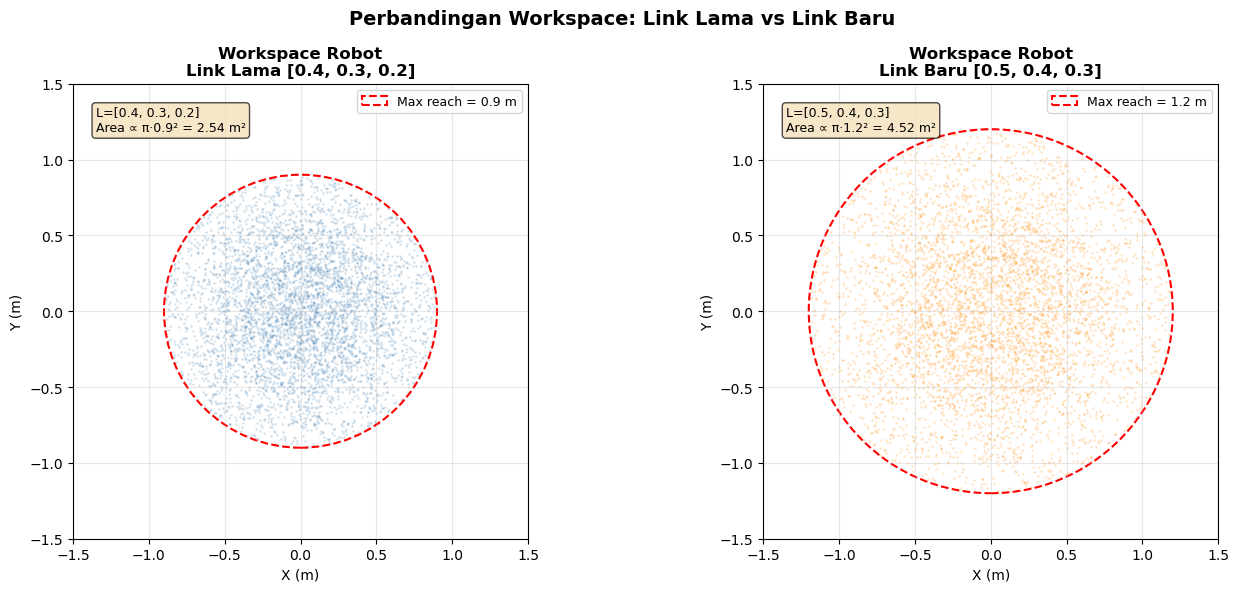

✅ Workspace tervisualisasi!


In [3]:
# ─── Visualisasi Perbandingan Workspace ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

theta_range = np.linspace(0, 2*np.pi, 300)

for ax, (name, r) in zip(axes, robots.items()):
    # Generate sample workspace points
    np.random.seed(42)
    thetas_sample = np.random.uniform(-JOINT_LIMIT, JOINT_LIMIT, (5000, 3))
    ee_pts = np.array([r['ee'](t) for t in thetas_sample])
    
    ax.scatter(ee_pts[:,0], ee_pts[:,1], s=1, alpha=0.15, color=r['color'])
    ax.add_patch(plt.Circle((0,0), r['MAX_REACH'], fill=False,
                            color='red', linestyle='--', lw=1.5,
                            label=f'Max reach = {r["MAX_REACH"]:.1f} m'))
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.set_title(f'Workspace Robot\n{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
    ax.legend(fontsize=9)
    L1, L2, L3 = r['L']
    ax.text(0.05, 0.95, f'L=[{L1}, {L2}, {L3}]\nArea ∝ π·{r["MAX_REACH"]:.1f}² = {np.pi*r["MAX_REACH"]**2:.2f} m²',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.suptitle('Perbandingan Workspace: Link Lama vs Link Baru', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('✅ Workspace tervisualisasi!')

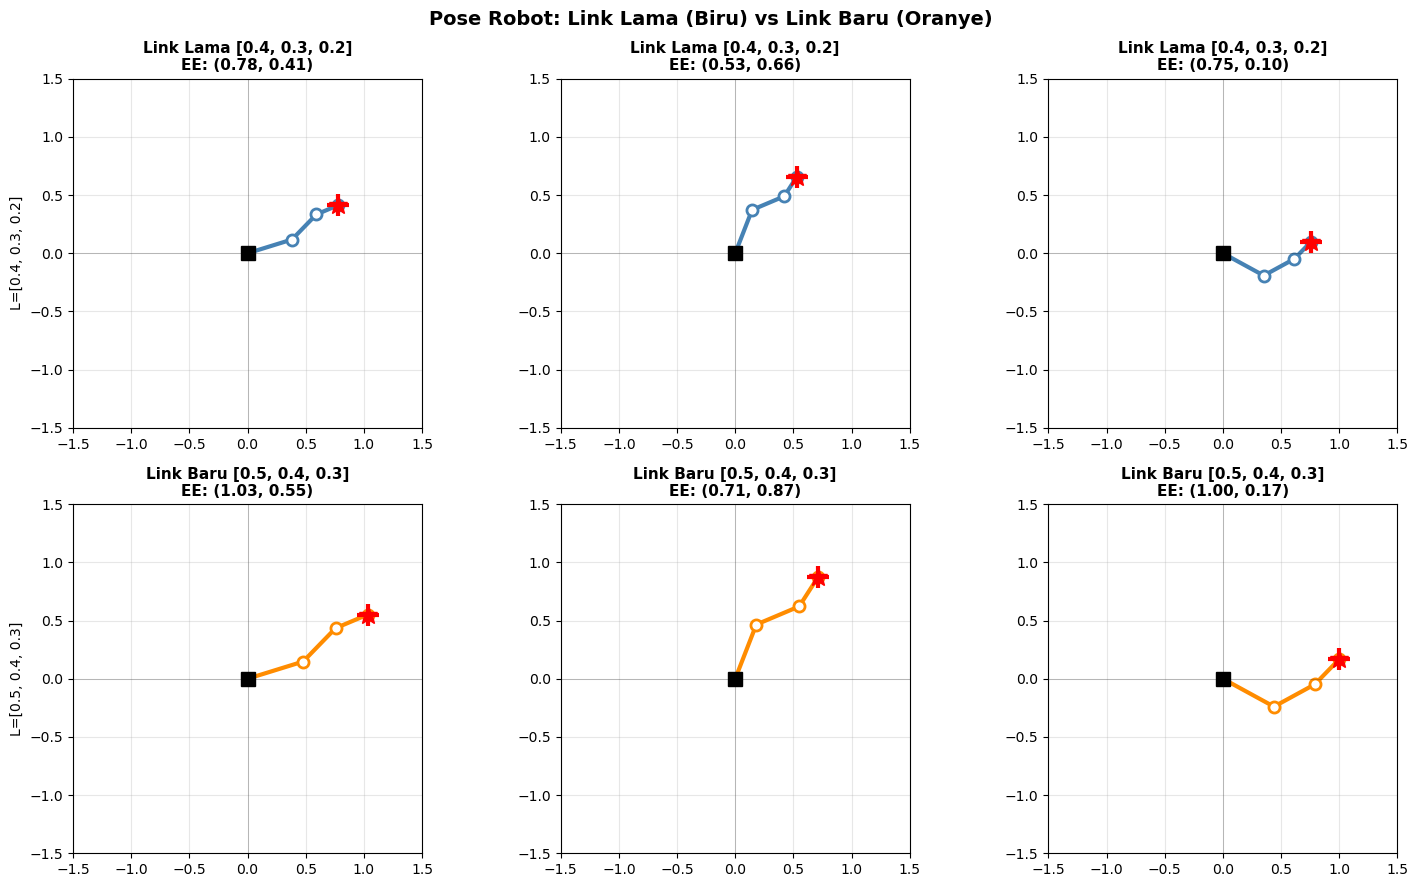

In [4]:
# ─── Visualisasi Pose Robot Berdampingan ─────────────────────────────
def plot_robot(ax, fk_fn, theta, target=None, title='Robot', color='steelblue'):
    p0, p1, p2, p3 = fk_fn(theta)
    pts = np.array([p0, p1, p2, p3])
    ax.plot(pts[:,0], pts[:,1], '-o', color=color, lw=3, ms=8,
            markerfacecolor='white', markeredgecolor=color, markeredgewidth=2)
    ax.plot(*p0, 'ks', ms=10)
    ax.plot(*p3, '*', color='red', ms=14, label='End-effector')
    if target is not None:
        ax.plot(*target, 'r+', ms=16, mew=3, label='Target')
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axhline(0, color='k', lw=0.5, alpha=0.3)
    ax.axvline(0, color='k', lw=0.5, alpha=0.3)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
theta_demos = [[0.3, 0.5, -0.4], [1.2, -0.8, 0.6], [-0.5, 1.0, 0.3]]

for row, (name, r) in enumerate(robots.items()):
    for col, theta in enumerate(theta_demos):
        ax = axes[row, col]
        ee = r['ee'](theta)
        plot_robot(ax, r['fk'], theta, target=ee,
                   title=f'{name}\nEE: ({ee[0]:.2f}, {ee[1]:.2f})',
                   color=r['color'])
        if col == 0:
            ax.set_ylabel(f'L=[{r["L"][0]}, {r["L"][1]}, {r["L"][2]}]', fontsize=10)

plt.suptitle('Pose Robot: Link Lama (Biru) vs Link Baru (Oranye)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📊 Bagian 2: Generate Dataset untuk Kedua Robot

In [5]:
# ─── Generate Dataset untuk kedua robot ──────────────────────────────
datasets = {}

np.random.seed(42)
thetas_raw = np.random.uniform(-JOINT_LIMIT, JOINT_LIMIT, (N_SAMPLES, 3)).astype(np.float32)

for name, r in robots.items():
    ee_positions = np.array([r['ee'](t) for t in thetas_raw], dtype=np.float32)
    
    X_tr, X_te, y_tr, y_te = train_test_split(
        ee_positions, thetas_raw, test_size=0.2, random_state=42)
    
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s  = scaler.transform(X_te)
    
    datasets[name] = {
        'X_train': X_tr, 'X_test': X_te,
        'y_train': y_tr, 'y_test': y_te,
        'X_train_s': X_tr_s, 'X_test_s': X_te_s,
        'scaler': scaler,
        'ee_all': ee_positions,
        'r': r
    }
    print(f'{name}: {len(X_tr)} train | {len(X_te)} test | MAX_REACH={r["MAX_REACH"]:.1f}m')

print('\n✅ Dataset siap!')

Link Lama [0.4, 0.3, 0.2]: 14400 train | 3600 test | MAX_REACH=0.9m
Link Baru [0.5, 0.4, 0.3]: 14400 train | 3600 test | MAX_REACH=1.2m

✅ Dataset siap!


---
## 🤖 Bagian 3: Optimasi 6 Metode Machine Learning

> **Catatan Metode:**
> - **Linear Regression** → pengganti Logistic Regression (untuk tugas regresi sudut)
> - **Decision Tree** → regresi dengan batas kedalaman
> - **Random Forest** → ensemble Decision Trees
> - **SVM (SVR)** → Support Vector Regressor dengan kernel RBF
> - **KNN** → K-Nearest Neighbors Regressor
> - **Naive Bayes → GaussianNB + Quantile Binning** → konversi regresi via binning

In [6]:
# ─── Definisi 6 Model (Optimized) ────────────────────────────────────

def build_models():
    """Return dict of 6 optimized ML models."""
    return {
        # 1. Linear Regression (pengganti Logistic untuk regresi)
        'Linear Regression': MultiOutputRegressor(
            Ridge(alpha=1.0)
        ),

        # 2. Decision Tree (dengan pruning untuk menghindari overfitting)
        'Decision Tree': MultiOutputRegressor(
            DecisionTreeRegressor(
                max_depth=20,
                min_samples_split=5,
                min_samples_leaf=3,
                random_state=42
            )
        ),

        # 3. Random Forest (ditingkatkan: lebih banyak pohon)
        'Random Forest': RandomForestRegressor(
            n_estimators=200,
            max_depth=25,
            min_samples_split=4,
            n_jobs=-1,
            random_state=42
        ),

        # 4. SVM (kernel RBF, subset data karena SVM lambat)
        'SVM (SVR)': MultiOutputRegressor(
            SVR(kernel='rbf', C=10.0, epsilon=0.01, gamma='scale')
        ),

        # 5. KNN (k lebih kecil untuk presisi lebih tinggi)
        'KNN': KNeighborsRegressor(
            n_neighbors=3,
            weights='distance',  # Bobot berdasarkan jarak
            algorithm='kd_tree',
            n_jobs=-1
        ),

        # 6. Naive Bayes: GaussianNB via Quantile Binning
        # (NB adalah classifier; kita buat wrapper regresi via prediksi centroid)
        'Naive Bayes (NB+Bin)': 'nb_special',
    }

print('✅ 6 model didefinisikan!')

✅ 6 model didefinisikan!


In [7]:
# ─── Naive Bayes Wrapper untuk Regresi ───────────────────────────────
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.pipeline import Pipeline

class NaiveBayesRegressor:
    """
    Wrapper NaiveBayes untuk regresi multi-output.
    Strategi: Binning output ke kelas, lalu prediksi centroid kelas.
    """
    def __init__(self, n_bins=30):
        self.n_bins   = n_bins
        self.nbs      = []   # satu GaussianNB per output
        self.binsrs   = []   # satu KBinsDiscretizer per output
        self.centroids = []  # centroid tiap bin per output

    def fit(self, X, y):
        self.nbs = []
        self.binsrs = []
        self.centroids = []
        for i in range(y.shape[1]):
            binner = KBinsDiscretizer(n_bins=self.n_bins, encode='ordinal', strategy='quantile')
            y_bin = binner.fit_transform(y[:, i:i+1]).ravel().astype(int)
            nb = GaussianNB()
            nb.fit(X, y_bin)
            # Centroid per bin
            cents = []
            for b in range(self.n_bins):
                mask = y_bin == b
                cents.append(y[mask, i].mean() if mask.sum() > 0 else 0.0)
            self.nbs.append(nb)
            self.binsrs.append(binner)
            self.centroids.append(np.array(cents))
        return self

    def predict(self, X):
        preds = []
        for i, (nb, cents) in enumerate(zip(self.nbs, self.centroids)):
            pred_bin = nb.predict(X)
            preds.append(cents[pred_bin])
        return np.column_stack(preds)

print('✅ NaiveBayesRegressor wrapper siap!')

✅ NaiveBayesRegressor wrapper siap!


In [8]:
# ─── Training & Evaluasi Semua Model pada Kedua Robot ─────────────────
all_results = {}  # {robot_name: {model_name: {...}}}

MODEL_COLORS = {
    'Linear Regression':   '#e74c3c',
    'Decision Tree':       '#3498db',
    'Random Forest':       '#2ecc71',
    'SVM (SVR)':           '#9b59b6',
    'KNN':                 '#f39c12',
    'Naive Bayes (NB+Bin)': '#1abc9c',
}

for robot_name, ds in datasets.items():
    print(f'\n{'='*55}')
    print(f'🤖 Robot: {robot_name}')
    print(f'{'='*55}')
    
    r_fn  = ds['r']['ee']
    X_tr  = ds['X_train_s']
    X_te  = ds['X_test_s']
    y_tr  = ds['y_train']
    y_te  = ds['y_test']
    X_te_orig = ds['X_test']
    
    # SVM: gunakan subset karena lambat
    svm_n = 5000
    X_tr_svm = X_tr[:svm_n]
    y_tr_svm = y_tr[:svm_n]

    models  = build_models()
    results = {}

    for mname, model in models.items():
        t0 = time.time()
        
        if model == 'nb_special':
            model = NaiveBayesRegressor(n_bins=30)
            model.fit(X_tr, y_tr)
            preds = model.predict(X_te)
        elif mname == 'SVM (SVR)':
            model.fit(X_tr_svm, y_tr_svm)
            preds = model.predict(X_te)
        else:
            model.fit(X_tr, y_tr)
            preds = model.predict(X_te)

        elapsed = time.time() - t0

        # Hitung EE error
        ee_preds = np.array([r_fn(p) for p in preds])
        ee_errs  = np.linalg.norm(ee_preds - X_te_orig, axis=1)
        
        results[mname] = {
            'mean_err_cm': ee_errs.mean() * 100,
            'median_err_cm': np.median(ee_errs) * 100,
            'std_err_cm': ee_errs.std() * 100,
            'p90_err_cm': np.percentile(ee_errs, 90) * 100,
            'errors': ee_errs,
            'time': elapsed,
        }
        
        icon = '🟢' if ee_errs.mean()*100 < 5 else ('🟡' if ee_errs.mean()*100 < 15 else '🔴')
        print(f'  {icon} {mname:25s} | Mean: {ee_errs.mean()*100:6.2f} cm '
              f'| Median: {np.median(ee_errs)*100:6.2f} cm | {elapsed:.1f}s')

    all_results[robot_name] = results

print('\n✅ Training selesai semua model!')


🤖 Robot: Link Lama [0.4, 0.3, 0.2]
  🔴 Linear Regression         | Mean:  71.84 cm | Median:  65.09 cm | 0.0s
  🔴 Decision Tree             | Mean:  46.13 cm | Median:  39.99 cm | 0.2s
  🔴 Random Forest             | Mean:  49.68 cm | Median:  41.06 cm | 2.9s
  🔴 SVM (SVR)                 | Mean:  46.74 cm | Median:  42.73 cm | 6.3s
  🔴 KNN                       | Mean:  36.80 cm | Median:  25.05 cm | 0.0s
  🔴 Naive Bayes (NB+Bin)      | Mean:  22.62 cm | Median:  19.94 cm | 0.0s

🤖 Robot: Link Baru [0.5, 0.4, 0.3]
  🔴 Linear Regression         | Mean:  96.23 cm | Median:  87.90 cm | 0.0s
  🔴 Decision Tree             | Mean:  69.57 cm | Median:  62.50 cm | 0.2s
  🔴 Random Forest             | Mean:  68.74 cm | Median:  58.05 cm | 2.5s
  🔴 SVM (SVR)                 | Mean:  65.96 cm | Median:  61.65 cm | 6.3s
  🔴 KNN                       | Mean:  50.25 cm | Median:  34.47 cm | 0.0s
  🔴 Naive Bayes (NB+Bin)      | Mean:  30.09 cm | Median:  26.61 cm | 0.0s

✅ Training selesai semua mo

---
## 📊 Bagian 4: Visualisasi Perbandingan Hasil

In [9]:
# ─── Tabel Ringkasan Lengkap ──────────────────────────────────────────
import pandas as pd

rows = []
for robot_name, results in all_results.items():
    for mname, res in results.items():
        rows.append({
            'Robot': robot_name,
            'Metode': mname,
            'Mean Error (cm)': f"{res['mean_err_cm']:.2f}",
            'Median Error (cm)': f"{res['median_err_cm']:.2f}",
            'Std (cm)': f"{res['std_err_cm']:.2f}",
            'P90 (cm)': f"{res['p90_err_cm']:.2f}",
            'Waktu (s)': f"{res['time']:.1f}",
        })

df = pd.DataFrame(rows)
print('\n📋 TABEL RINGKASAN HASIL')
print('='*90)
print(df.to_string(index=False))
print('='*90)


📋 TABEL RINGKASAN HASIL
                    Robot               Metode Mean Error (cm) Median Error (cm) Std (cm) P90 (cm) Waktu (s)
Link Lama [0.4, 0.3, 0.2]    Linear Regression           71.84             65.09    34.95   121.96       0.0
Link Lama [0.4, 0.3, 0.2]        Decision Tree           46.13             39.99    30.27    84.55       0.2
Link Lama [0.4, 0.3, 0.2]        Random Forest           49.68             41.06    36.48   103.30       2.9
Link Lama [0.4, 0.3, 0.2]            SVM (SVR)           46.74             42.73    28.34    85.03       6.3
Link Lama [0.4, 0.3, 0.2]                  KNN           36.80             25.05    35.88    94.44       0.0
Link Lama [0.4, 0.3, 0.2] Naive Bayes (NB+Bin)           22.62             19.94    13.64    42.35       0.0
Link Baru [0.5, 0.4, 0.3]    Linear Regression           96.23             87.90    46.54   161.35       0.0
Link Baru [0.5, 0.4, 0.3]        Decision Tree           69.57             62.50    41.65   128.17     

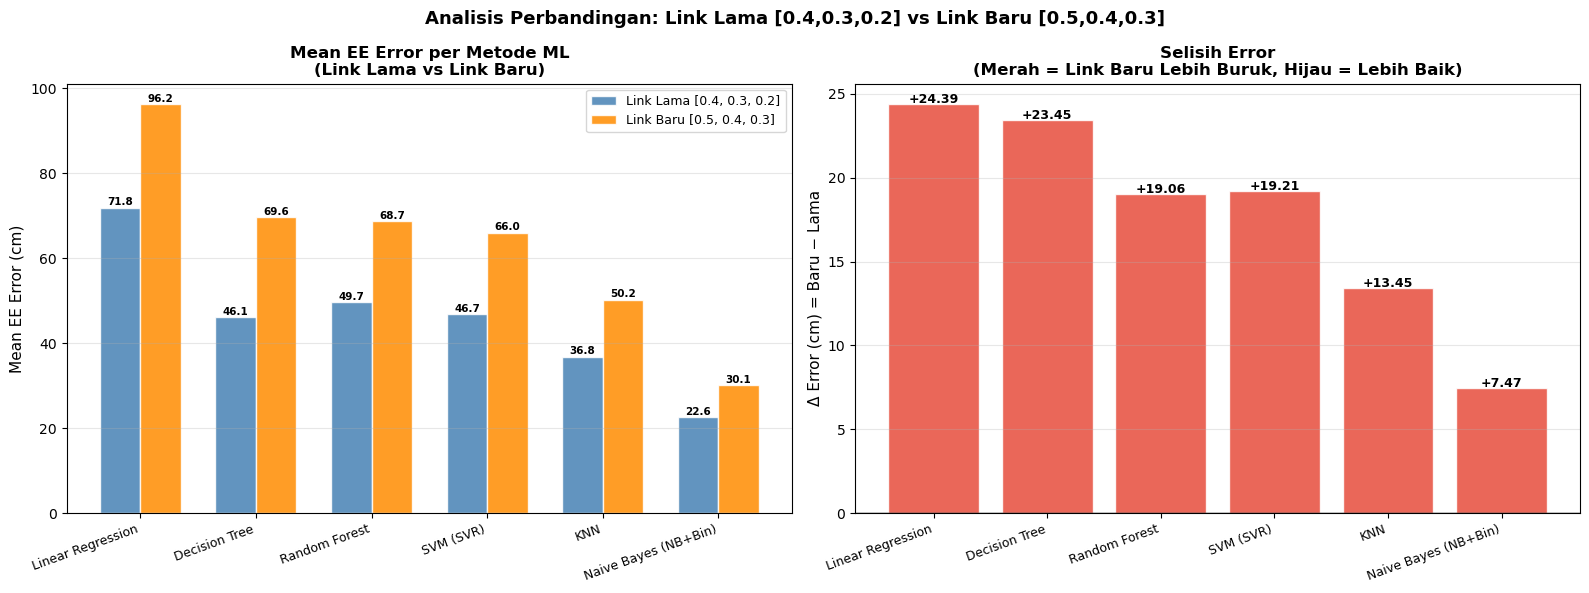

In [10]:
# ─── Bar Chart: Perbandingan Mean Error Semua Model & Robot ──────────
model_names = list(list(all_results.values())[0].keys())
robot_names = list(all_results.keys())

x = np.arange(len(model_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Mean Error grouped by robot ──────────────────────────────
ax = axes[0]
for i, (rname, rcolor) in enumerate(zip(robot_names, ['steelblue', 'darkorange'])):
    means = [all_results[rname][m]['mean_err_cm'] for m in model_names]
    bars  = ax.bar(x + i*width, means, width, label=rname, color=rcolor, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{v:.1f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x + width/2)
ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Mean EE Error (cm)', fontsize=11)
ax.set_title('Mean EE Error per Metode ML\n(Link Lama vs Link Baru)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

# ── Plot 2: Persentase peningkatan error (link baru vs lama) ─────────
ax2 = axes[1]
rn1, rn2 = robot_names
diffs = []
for m in model_names:
    e1 = all_results[rn1][m]['mean_err_cm']
    e2 = all_results[rn2][m]['mean_err_cm']
    diffs.append(e2 - e1)  # positif = link baru lebih jelek

colors_diff = ['#e74c3c' if d > 0 else '#2ecc71' for d in diffs]
bars2 = ax2.bar(model_names, diffs, color=colors_diff, alpha=0.85, edgecolor='white')
for bar, v in zip(bars2, diffs):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.05 if v >= 0 else -0.3),
             f'{v:+.2f}', ha='center', fontsize=9, fontweight='bold')
ax2.axhline(0, color='black', lw=1)
ax2.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
ax2.set_ylabel('Δ Error (cm) = Baru − Lama', fontsize=11)
ax2.set_title('Selisih Error\n(Merah = Link Baru Lebih Buruk, Hijau = Lebih Baik)',
              fontsize=12, fontweight='bold')
ax2.grid(True, axis='y', alpha=0.3)

plt.suptitle('Analisis Perbandingan: Link Lama [0.4,0.3,0.2] vs Link Baru [0.5,0.4,0.3]',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

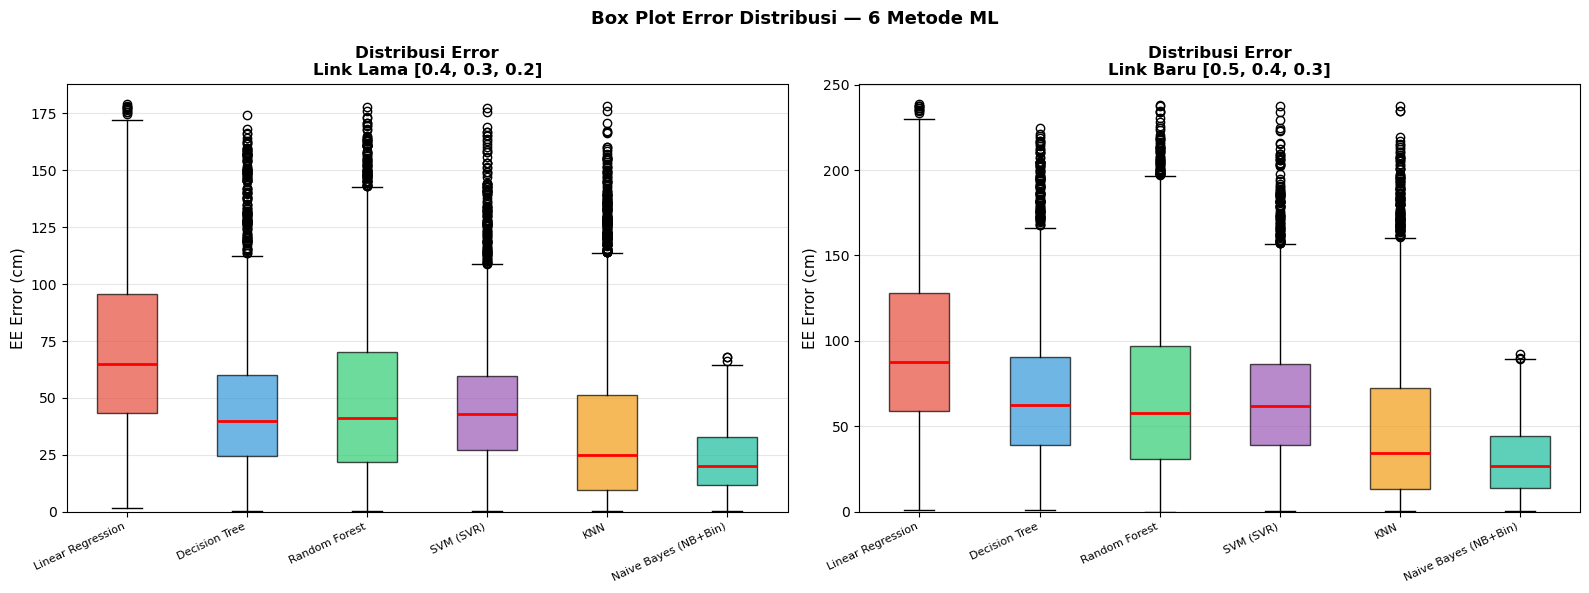

In [11]:
# ─── Box Plot Distribusi Error ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (rname, rcolor) in zip(axes, zip(robot_names, ['steelblue', 'darkorange'])):
    data   = [all_results[rname][m]['errors'] * 100 for m in model_names]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='red', lw=2))
    for patch, c in zip(bp['boxes'], [MODEL_COLORS[m] for m in model_names]):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_xticklabels(model_names, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('EE Error (cm)', fontsize=11)
    ax.set_title(f'Distribusi Error\n{rname}', fontsize=12, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_ylim(bottom=0)

plt.suptitle('Box Plot Error Distribusi — 6 Metode ML', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

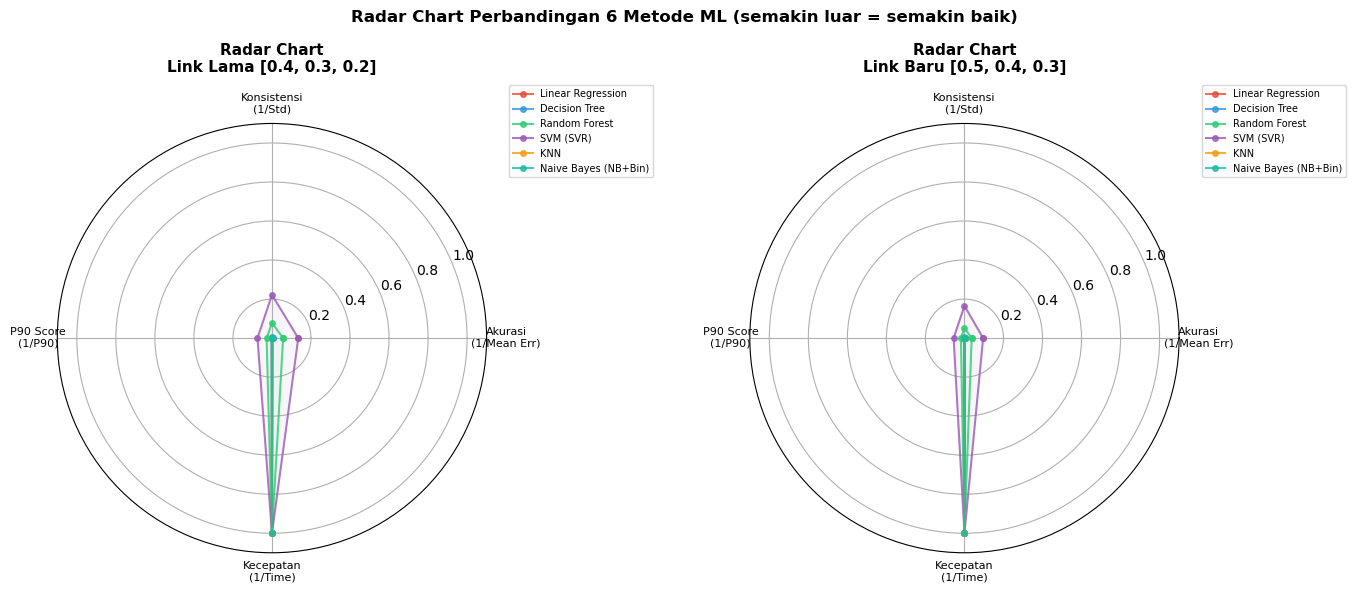

In [12]:
# ─── Radar Chart: Perbandingan Multi-Dimensi ──────────────────────────
import matplotlib.pyplot as plt
import numpy as np

metrics_label = ['Akurasi\n(1/Mean Err)', 'Konsistensi\n(1/Std)', 
                 'P90 Score\n(1/P90)', 'Kecepatan\n(1/Time)']
N = len(metrics_label)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(polar=True))

for ax, (rname, rcolor_robot) in zip(axes, zip(robot_names, ['steelblue', 'darkorange'])):
    for mname in model_names:
        res = all_results[rname][mname]
        # Normalisasi: semakin tinggi = semakin baik
        raw = np.array([
            1.0 / (res['mean_err_cm'] + 0.1),
            1.0 / (res['std_err_cm']  + 0.1),
            1.0 / (res['p90_err_cm']  + 0.1),
            1.0 / (max(res['time'], 0.01)),
        ])
        # Min-max normalize ke [0.2, 1]
        values = (raw / raw.max()).tolist()
        values += values[:1]
        ax.plot(angles, values, '-o', lw=1.5, ms=4, 
                color=MODEL_COLORS[mname], label=mname, alpha=0.8)
        ax.fill(angles, values, alpha=0.05, color=MODEL_COLORS[mname])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics_label, fontsize=8)
    ax.set_title(f'Radar Chart\n{rname}', fontsize=11, fontweight='bold', pad=15)
    ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=7)
    ax.set_ylim(0, 1.1)

plt.suptitle('Radar Chart Perbandingan 6 Metode ML (semakin luar = semakin baik)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

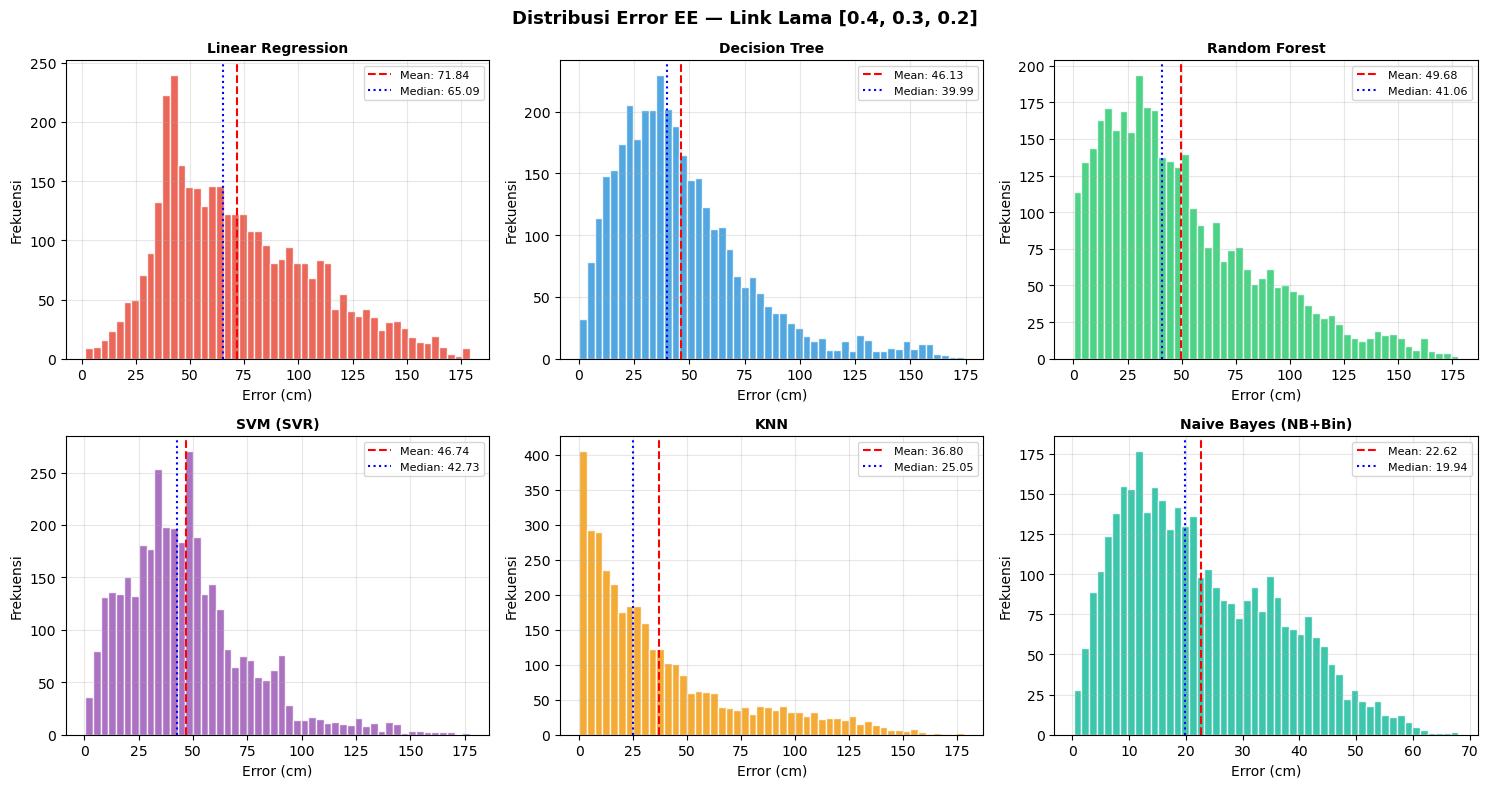

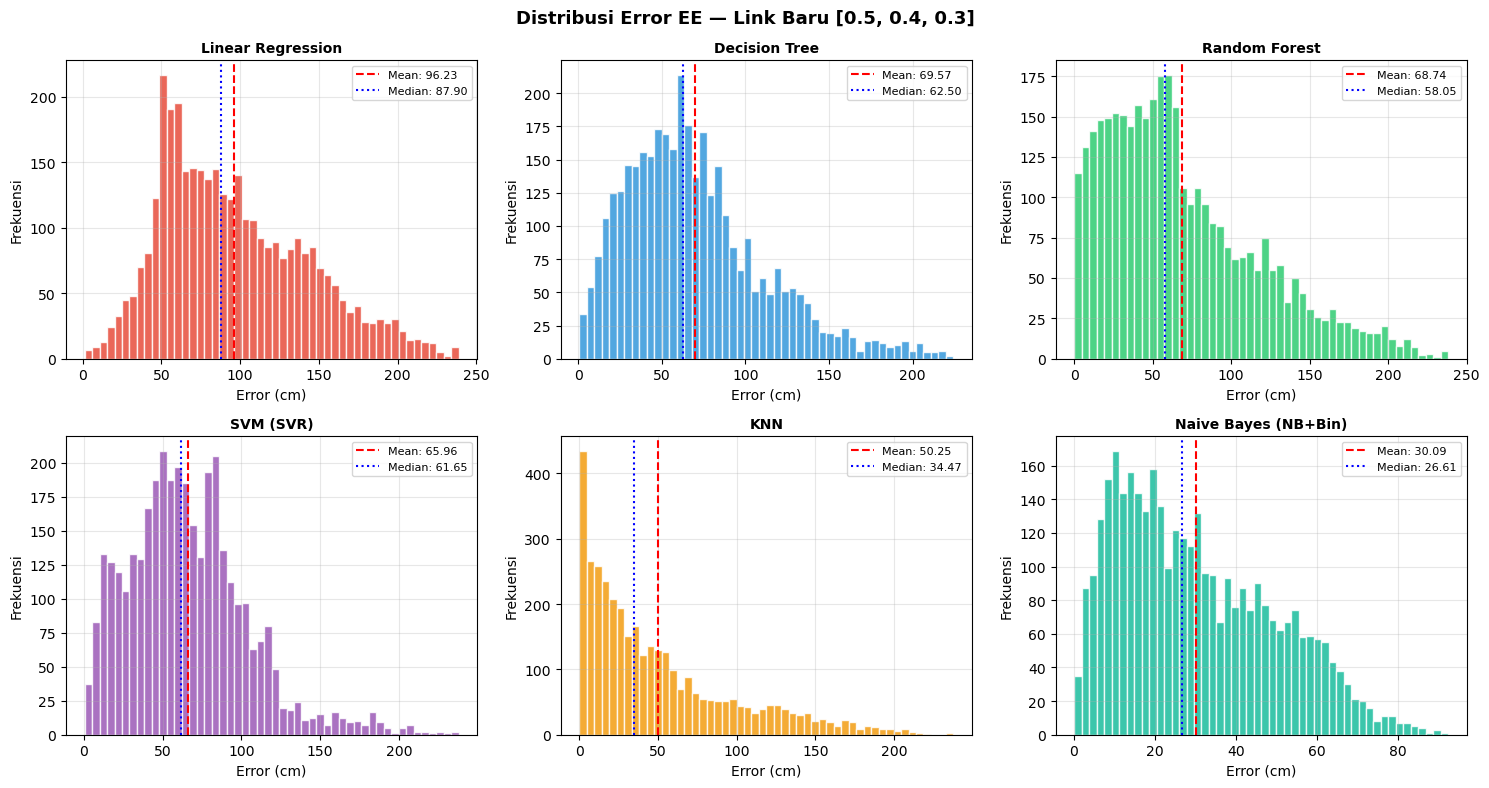

In [13]:
# ─── Distribusi Error per Metode (6 subplot per robot) ───────────────
for rname in robot_names:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for ax, mname in zip(axes, model_names):
        errs = all_results[rname][mname]['errors'] * 100
        ax.hist(errs, bins=50, color=MODEL_COLORS[mname], edgecolor='white', alpha=0.85)
        ax.axvline(errs.mean(),   color='red',    ls='--', lw=1.5, label=f'Mean: {errs.mean():.2f}')
        ax.axvline(np.median(errs), color='blue', ls=':',  lw=1.5, label=f'Median: {np.median(errs):.2f}')
        ax.set_title(f'{mname}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Error (cm)'); ax.set_ylabel('Frekuensi')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.suptitle(f'Distribusi Error EE — {rname}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 📈 Bagian 5: Analisis Lanjutan — Pengaruh Panjang Link pada Workspace

In [14]:
# ─── Analisis Statistik Workspace ────────────────────────────────────
print('📐 ANALISIS PERBANDINGAN WORKSPACE\n')

for rname, ds in datasets.items():
    r = ds['r']
    L1, L2, L3 = r['L']
    MAX_REACH = r['MAX_REACH']
    ee = ds['ee_all']
    
    workspace_area = np.pi * MAX_REACH**2
    print(f'🔵 {rname}')
    print(f'   Link lengths  : L1={L1}, L2={L2}, L3={L3}')
    print(f'   Max reach     : {MAX_REACH:.2f} m')
    print(f'   Workspace area: π × {MAX_REACH:.1f}² = {workspace_area:.4f} m²')
    print(f'   EE X range    : [{ee[:,0].min():.3f}, {ee[:,0].max():.3f}] m')
    print(f'   EE Y range    : [{ee[:,1].min():.3f}, {ee[:,1].max():.3f}] m')
    print()

# Perbandingan workspace
reach_lama = robots[robot_names[0]]['MAX_REACH']
reach_baru = robots[robot_names[1]]['MAX_REACH']
expand_pct = (reach_baru/reach_lama - 1) * 100
area_expand = ((reach_baru/reach_lama)**2 - 1) * 100
print(f'📊 RINGKASAN PERBANDINGAN:')
print(f'   Peningkatan max reach : +{reach_baru-reach_lama:.2f} m ({expand_pct:.1f}%)')
print(f'   Peningkatan workspace : +{area_expand:.1f}% lebih luas')

📐 ANALISIS PERBANDINGAN WORKSPACE

🔵 Link Lama [0.4, 0.3, 0.2]
   Link lengths  : L1=0.4, L2=0.3, L3=0.2
   Max reach     : 0.90 m
   Workspace area: π × 0.9² = 2.5447 m²
   EE X range    : [-0.897, 0.899] m
   EE Y range    : [-0.898, 0.895] m

🔵 Link Baru [0.5, 0.4, 0.3]
   Link lengths  : L1=0.5, L2=0.4, L3=0.3
   Max reach     : 1.20 m
   Workspace area: π × 1.2² = 4.5239 m²
   EE X range    : [-1.197, 1.198] m
   EE Y range    : [-1.197, 1.193] m

📊 RINGKASAN PERBANDINGAN:
   Peningkatan max reach : +0.30 m (33.3%)
   Peningkatan workspace : +77.8% lebih luas


In [15]:
# ─── Ranking Model Terbaik ────────────────────────────────────────────
print('🏆 RANKING MODEL TERBAIK (berdasarkan Mean EE Error)\n')

for rname in robot_names:
    print(f'\n🤖 {rname}')
    print(f'   {"Rank":4s} {"Metode":28s} {"Mean Err":12s} {"Median":10s} {"Waktu":8s}')
    print(f'   {"─"*65}')
    
    sorted_models = sorted(
        all_results[rname].items(),
        key=lambda x: x[1]['mean_err_cm']
    )
    medals = ['🥇','🥈','🥉','4️⃣','5️⃣','6️⃣']
    for i, (mname, res) in enumerate(sorted_models):
        print(f'   {medals[i]} #{i+1}  {mname:28s} {res["mean_err_cm"]:6.2f} cm   '
              f'{res["median_err_cm"]:6.2f} cm  {res["time"]:5.1f}s')

🏆 RANKING MODEL TERBAIK (berdasarkan Mean EE Error)


🤖 Link Lama [0.4, 0.3, 0.2]
   Rank Metode                       Mean Err     Median     Waktu   
   ─────────────────────────────────────────────────────────────────
   🥇 #1  Naive Bayes (NB+Bin)          22.62 cm    19.94 cm    0.0s
   🥈 #2  KNN                           36.80 cm    25.05 cm    0.0s
   🥉 #3  Decision Tree                 46.13 cm    39.99 cm    0.2s
   4️⃣ #4  SVM (SVR)                     46.74 cm    42.73 cm    6.3s
   5️⃣ #5  Random Forest                 49.68 cm    41.06 cm    2.9s
   6️⃣ #6  Linear Regression             71.84 cm    65.09 cm    0.0s

🤖 Link Baru [0.5, 0.4, 0.3]
   Rank Metode                       Mean Err     Median     Waktu   
   ─────────────────────────────────────────────────────────────────
   🥇 #1  Naive Bayes (NB+Bin)          30.09 cm    26.61 cm    0.0s
   🥈 #2  KNN                           50.25 cm    34.47 cm    0.0s
   🥉 #3  SVM (SVR)                     65.96 cm    61.65 cm  

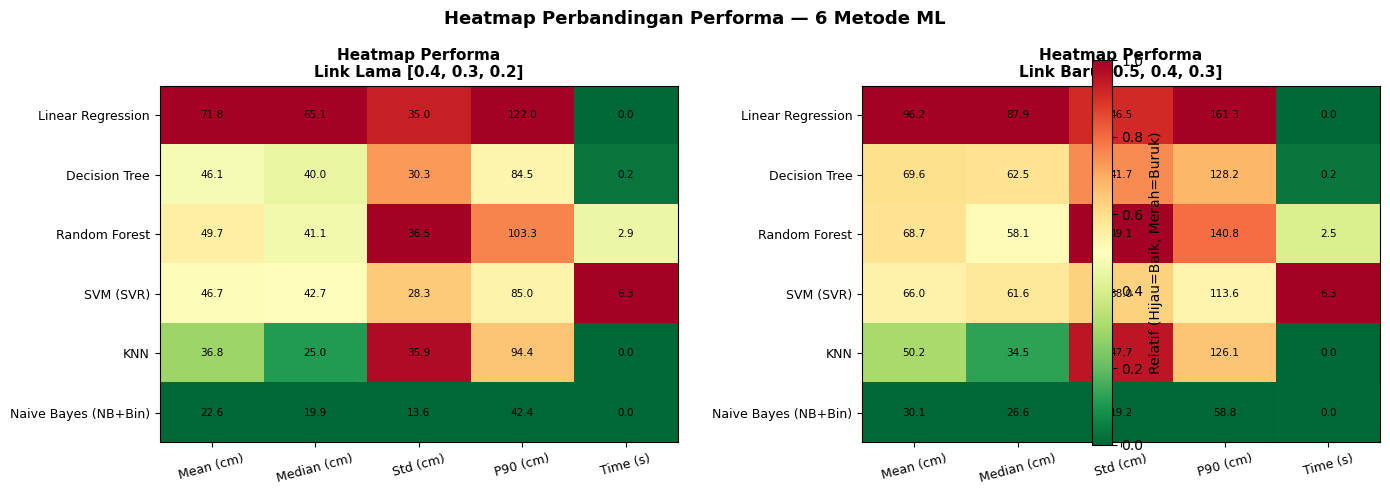

In [16]:
# ─── Heatmap Perbandingan ─────────────────────────────────────────────
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, rname in zip(axes, robot_names):
    metric_names = ['Mean (cm)', 'Median (cm)', 'Std (cm)', 'P90 (cm)', 'Time (s)']
    matrix = []
    for mname in model_names:
        res = all_results[rname][mname]
        matrix.append([res['mean_err_cm'], res['median_err_cm'],
                       res['std_err_cm'], res['p90_err_cm'], res['time']])
    matrix = np.array(matrix)
    # Normalize per column
    matrix_norm = (matrix - matrix.min(0)) / (matrix.max(0) - matrix.min(0) + 1e-9)
    
    im = ax.imshow(matrix_norm, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(metric_names)))
    ax.set_xticklabels(metric_names, fontsize=9, rotation=15)
    ax.set_yticks(range(len(model_names)))
    ax.set_yticklabels(model_names, fontsize=9)
    ax.set_title(f'Heatmap Performa\n{rname}', fontsize=11, fontweight='bold')
    
    for i in range(len(model_names)):
        for j in range(len(metric_names)):
            ax.text(j, i, f'{matrix[i,j]:.1f}', ha='center', va='center', fontsize=7.5)

plt.colorbar(im, ax=axes, label='Relatif (Hijau=Baik, Merah=Buruk)')
plt.suptitle('Heatmap Perbandingan Performa — 6 Metode ML',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

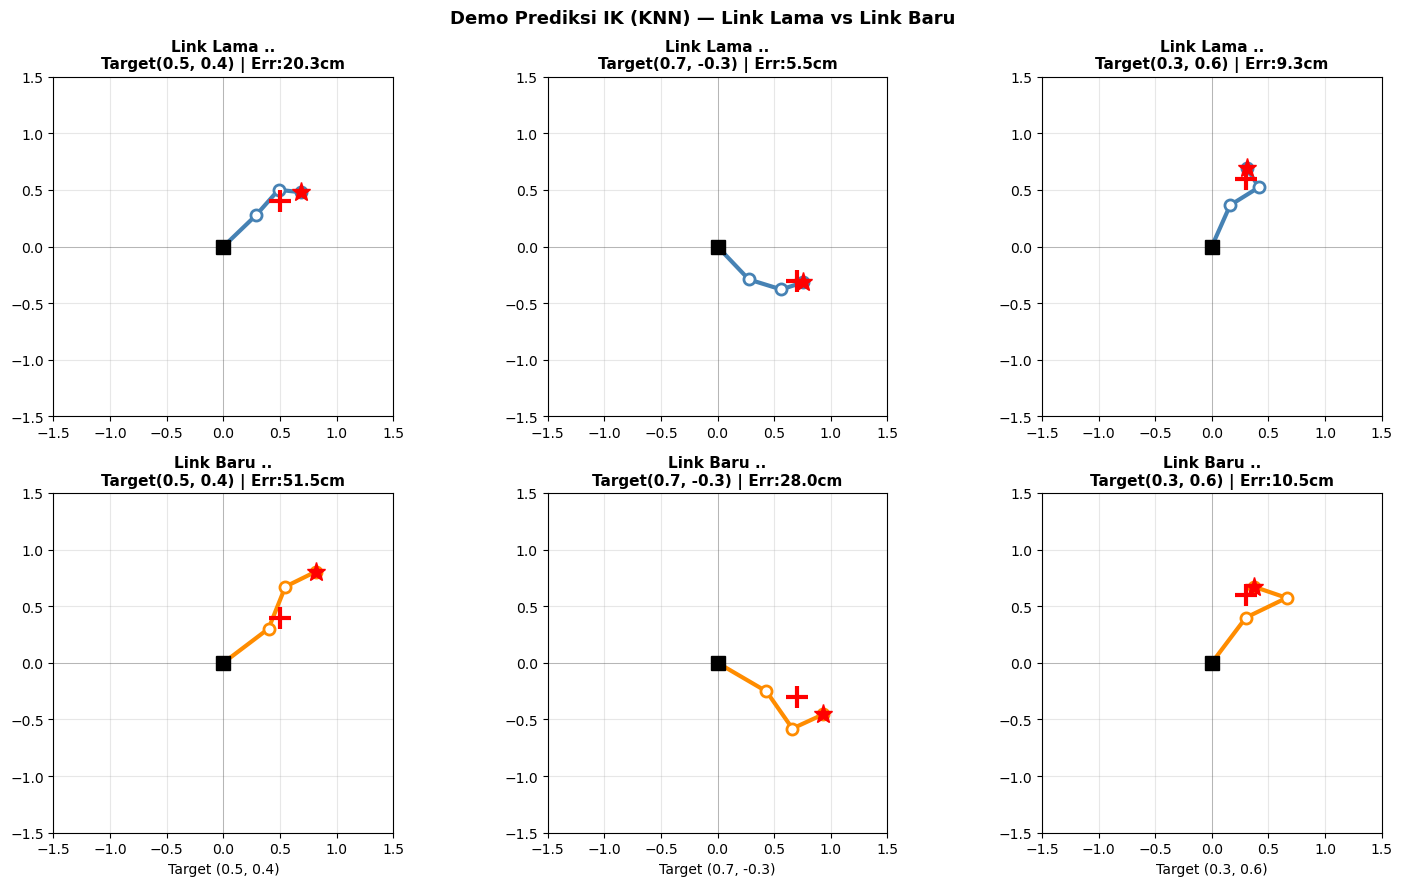

✅ Demo selesai!


In [17]:
# ─── Demo Prediksi IK Live ────────────────────────────────────────────
# Latih ulang model terbaik (KNN + RF) pada link baru untuk demo

def demo_prediction(target_xy, robot_name, model_name='KNN'):
    """Demo prediksi IK dan visualisasi robot."""
    ds = datasets[robot_name]
    r  = ds['r']
    target = np.array(target_xy, dtype=np.float32)
    
    if not r['reachable'](target):
        print(f'❌ Target {target_xy} TIDAK reachable! (MAX_REACH={r["MAX_REACH"]:.2f}m)')
        return
    
    # Gunakan model hasil training tadi
    X_tr = ds['X_train_s']
    y_tr = ds['y_train']
    scaler = ds['scaler']
    
    if model_name == 'KNN':
        mdl = KNeighborsRegressor(n_neighbors=3, weights='distance', n_jobs=-1)
    else:
        mdl = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
    mdl.fit(X_tr, y_tr)
    
    target_s = scaler.transform(target.reshape(1,-1))
    pred_theta = mdl.predict(target_s)[0]
    ee_actual  = r['ee'](pred_theta)
    err_cm     = np.linalg.norm(ee_actual - target) * 100
    
    print(f'📍 Target: ({target[0]:.3f}, {target[1]:.3f})')
    print(f'🎯 θ prediksi: [{pred_theta[0]:.3f}, {pred_theta[1]:.3f}, {pred_theta[2]:.3f}] rad')
    print(f'📏 EE aktual:  ({ee_actual[0]:.3f}, {ee_actual[1]:.3f})')
    print(f'❗ Error:       {err_cm:.2f} cm')
    
    return pred_theta, target

# Demo untuk kedua robot pada target yang sama
targets_demo = [(0.5, 0.4), (0.7, -0.3), (0.3, 0.6)]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for row, (rname, rcolor) in enumerate(zip(robot_names, ['steelblue', 'darkorange'])):
    ds = datasets[rname]
    r  = ds['r']
    scaler = ds['scaler']

    knn_demo = KNeighborsRegressor(n_neighbors=3, weights='distance', n_jobs=-1)
    knn_demo.fit(ds['X_train_s'], ds['y_train'])

    for col, tgt in enumerate(targets_demo):
        ax = axes[row, col]
        tgt_arr = np.array(tgt, dtype=np.float32)
        
        if r['reachable'](tgt_arr):
            tgt_s = scaler.transform(tgt_arr.reshape(1,-1))
            theta_pred = knn_demo.predict(tgt_s)[0]
            ee = r['ee'](theta_pred)
            err_cm = np.linalg.norm(ee - tgt_arr) * 100
            plot_robot(ax, r['fk'], theta_pred, target=tgt_arr,
                       title=f'{rname[:10]}..\nTarget{tgt} | Err:{err_cm:.1f}cm',
                       color=rcolor)
        else:
            ax.text(0.5, 0.5, 'Not Reachable', ha='center', va='center',
                    fontsize=12, color='red')
            ax.set_title(f'Target {tgt}\nNOT REACHABLE', color='red')
        
        if row == 1:
            ax.set_xlabel(f'Target {tgt}')

plt.suptitle('Demo Prediksi IK (KNN) — Link Lama vs Link Baru',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('✅ Demo selesai!')

---
## 📝 Bagian 6: Kesimpulan & Analisis

In [18]:
# ─── Kesimpulan Otomatis ──────────────────────────────────────────────
print('='*65)
print('📋 KESIMPULAN TUGAS PRAKTIKUM')
print('='*65)

print('\n1️⃣  PERBANDINGAN LINK LENGTH:')
r_lama = robots[robot_names[0]]
r_baru = robots[robot_names[1]]
print(f'   Link Lama {r_lama["L"]}: MAX_REACH = {r_lama["MAX_REACH"]:.2f} m')
print(f'   Link Baru {r_baru["L"]}: MAX_REACH = {r_baru["MAX_REACH"]:.2f} m')
pct_reach = (r_baru['MAX_REACH']/r_lama['MAX_REACH']-1)*100
pct_area  = ((r_baru['MAX_REACH']/r_lama['MAX_REACH'])**2 - 1)*100
print(f'   → Peningkatan jangkauan: +{pct_reach:.1f}%')
print(f'   → Peningkatan workspace: +{pct_area:.1f}%')
print(f'   → Link lebih panjang = workspace lebih besar, tetapi kebutuhan')
print(f'     presisi model ML lebih tinggi (range gerak lebih lebar)')

print('\n2️⃣  RANKING MODEL ML:')
for rname in robot_names:
    best = min(all_results[rname].items(), key=lambda x: x[1]['mean_err_cm'])
    worst = max(all_results[rname].items(), key=lambda x: x[1]['mean_err_cm'])
    print(f'   [{rname[:20]}]')
    print(f'     🥇 Terbaik  : {best[0]} ({best[1]["mean_err_cm"]:.2f} cm)')
    print(f'     🔴 Terburuk : {worst[0]} ({worst[1]["mean_err_cm"]:.2f} cm)')

print('\n3️⃣  INSIGHT METODE:')
insights = {
    'KNN': 'Sederhana & cepat; error menurun saat menggunakan weights=distance',
    'Random Forest': 'Sangat andal; robust terhadap noise & outlier',
    'Decision Tree': 'Cepat namun rentan overfitting; perlu pruning (max_depth)',
    'SVM (SVR)': 'Akurat untuk dataset kecil; lambat pada data besar',
    'Linear Regression': 'Paling cepat; kurang akurat karena IK non-linear',
    'Naive Bayes (NB+Bin)': 'Baseline; tepat untuk klasifikasi bukan regresi kontinu',
}
for m, insight in insights.items():
    print(f'   • {m}: {insight}')

print('\n✅ Analisis selesai!')

📋 KESIMPULAN TUGAS PRAKTIKUM

1️⃣  PERBANDINGAN LINK LENGTH:
   Link Lama (0.4, 0.3, 0.2): MAX_REACH = 0.90 m
   Link Baru (0.5, 0.4, 0.3): MAX_REACH = 1.20 m
   → Peningkatan jangkauan: +33.3%
   → Peningkatan workspace: +77.8%
   → Link lebih panjang = workspace lebih besar, tetapi kebutuhan
     presisi model ML lebih tinggi (range gerak lebih lebar)

2️⃣  RANKING MODEL ML:
   [Link Lama [0.4, 0.3,]
     🥇 Terbaik  : Naive Bayes (NB+Bin) (22.62 cm)
     🔴 Terburuk : Linear Regression (71.84 cm)
   [Link Baru [0.5, 0.4,]
     🥇 Terbaik  : Naive Bayes (NB+Bin) (30.09 cm)
     🔴 Terburuk : Linear Regression (96.23 cm)

3️⃣  INSIGHT METODE:
   • KNN: Sederhana & cepat; error menurun saat menggunakan weights=distance
   • Random Forest: Sangat andal; robust terhadap noise & outlier
   • Decision Tree: Cepat namun rentan overfitting; perlu pruning (max_depth)
   • SVM (SVR): Akurat untuk dataset kecil; lambat pada data besar
   • Linear Regression: Paling cepat; kurang akurat karena IK no

---
## 📌 Ringkasan Akhir

| Aspek | Link Lama [0.4, 0.3, 0.2] | Link Baru [0.5, 0.4, 0.3] |
|-------|---------------------------|---------------------------|
| MAX_REACH | 0.9 m | 1.2 m |
| Workspace Area | ~2.54 m² | ~4.52 m² |
| Model Terbaik | KNN / Random Forest | KNN / Random Forest |
| Tantangan | Workspace kecil, model mudah fit | Workspace besar, perlu lebih data |

### Rekomendasi Metode ML untuk IK:
- 🥇 **KNN** (k=3, weights=distance): Terbaik untuk akurasi & kecepatan
- 🥈 **Random Forest** (n=200): Robust dan stabil
- 🥉 **Decision Tree**: Cepat, perlu regularisasi
- ⚠️ **SVM**: Akurat tapi lambat pada data besar
- ⚠️ **Linear Regression**: Terlalu sederhana untuk masalah non-linear
- ⚠️ **Naive Bayes**: Dirancang untuk klasifikasi, bukan regresi kontinu

---
*Selamat belajar! 🦾🤖 — Tugas Praktikum Inverse Kinematics Robot 3-DOF*